#### Feature Selections

##### Imports

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path

##### Files

In [5]:
BASE_DIR = Path.cwd().parent
SPLITS_DIR = BASE_DIR / "data" / "splits"

In [6]:
df = pd.read_csv(SPLITS_DIR / "train.csv")

##### Drop Metadata

In [15]:
# drop name, team abbreviation, and season columns
df.drop(columns=["name", "TEAM_ABBREVIATION", "season"], inplace=True)

##### All Features

In [16]:
features = list(df.columns)

##### Correlation Analysis
This will help determine what features overlap or are repeated so that I don't need to include them in the final features

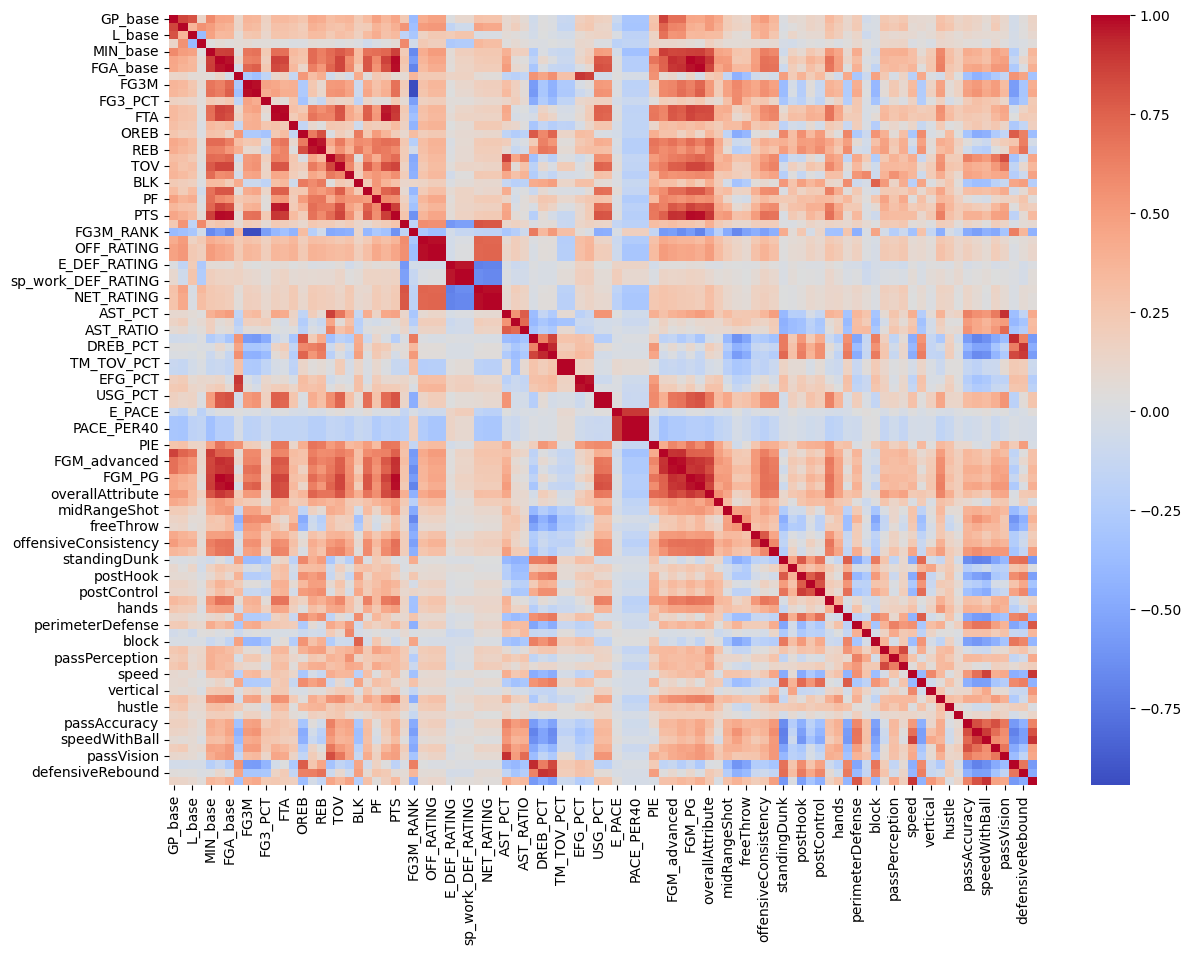

In [17]:
corr = df[features].corr()

plt.figure(figsize=(14,10))

sns.heatmap(corr, cmap="coolwarm")

plt.show()

Learnings:

- From this graph, it's seen that the diagonal ones are extremely red, meaning that they correlate with each other the most. This is expected as both the x and y labels are the same so they will exactly overlap each other.

- Usage percentage also correlates heavily to field goals made, because of this, it makes sense to remove usage percentage just so there's no bias learned within the AI that somehow gives higher attribute points to players with higher usage.

- A lot of the core stats (PTS, REB, FTs, TO, BLK, etc) are used to weigh in heavily on the overall attributes and FGM_PG. It seems to be that the overall attribute is rather constructed from more of the general stats rather than using a lot of the advanced stuff.

- [DEF_RATING, E_DEF_RATING, sp_work_DEF_RATING] tend to correlate heavily (this was also verified by AI). This tells me that not all of these stats might be needed as such and rather we can keep only one of them as they might operate in extremely similar fashions.

- [NET_RATING, E_NET_RATING, sp_work_NET_RATING] same goes for these three stats

- [FGM_base, FGM_advanced, FGM_PG] same for these three

- [FGA_base, FGA_advanced, FGA_PG] same for these three

- An interesting one I've noted is that stats like speedWithBall and passVision are heavily negatively correlated (bluer) with interiorDefense and block. This shows tends to show the archetypes of guards (who are more shifty and have courtvision) and bigs (who are a huge defensive upside)